In [7]:
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [8]:
load_dotenv()
model =  ChatOllama(model = "gemma4:latest", temperature= 0.5)

# define the State
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [9]:
# define the methord
def chat_node(State: ChatState):
    # define the properties
    messages = State['messages']
    response = model.invoke(messages)
    return {'messages':[response]}

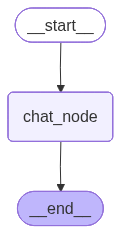

In [10]:
graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node', chat_node)

# add edge
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile()
chatbot


In [11]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

result = chatbot.invoke(initial_state)['messages'][-1].content
print(result)

ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it